# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [4]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [5]:
# Your code here
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Drop identifier and target-leakage columns (Keep 'mnth' for categorical encoding)
leak_cols = [c for c in ['instant', 'dteday', 'casual', 'registered'] if c in X_train.columns]
X_train_clean = X_train.drop(columns=leak_cols)
X_test_clean = X_test.drop(columns=leak_cols)

# 2. Define feature groups
categorical_cols = [c for c in ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
                    if c in X_train_clean.columns]
numerical_cols = [c for c in ['temp', 'atemp', 'hum', 'windspeed']
                  if c in X_train_clean.columns]

# 3. Build and apply Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit on training data and transform both sets
X_train_enc_array = preprocessor.fit_transform(X_train_clean)
X_test_enc_array = preprocessor.transform(X_test_clean)

# Retrieve processed feature names and convert back to DataFrames
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(numerical_cols) + list(encoded_cat_cols)

X_train_enc = pd.DataFrame(X_train_enc_array, columns=feature_names, index=X_train.index)
X_test_enc = pd.DataFrame(X_test_enc_array, columns=feature_names, index=X_test.index)

print(f"Processed Training Shape: {X_train_enc.shape}")
print(f"Processed Testing Shape:  {X_test_enc.shape}")
X_train_enc.head()

Processed Training Shape: (13903, 53)
Processed Testing Shape:  (3476, 53)


,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3,weathersit_4
335,-1.540837,-1.620311,-0.399449,0.278669,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7035,0.117112,0.138228,-1.073743,-0.697714,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8051,-0.193753,-0.125843,1.934646,0.278669,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2133,-0.193753,-0.125843,-1.644299,-1.552252,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8485,-1.540837,-1.444457,0.637926,-0.697714,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [6]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import xgboost as xgb

# Define hyperparameter distribution search space
xgb_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 6),
    'learning_rate': uniform(0.01, 0.1),
    'subsample': uniform(0.7, 0.3)
}

# Initialize RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit on the PREPROCESSED training features
xgb_search.fit(X_train_enc, y_train)

# Print the best parameters found
best_params = xgb_search.best_params_
print("Best Hyperparameters:", best_params)
print(f"Best CV R2 Score: {xgb_search.best_score_:.4f}")

Best Hyperparameters: {'learning_rate': np.float64(0.08272719958564209), 'max_depth': 5, 'n_estimators': 299, 'subsample': np.float64(0.8711331923216198)}
Best CV R2 Score: 0.9190


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [7]:
# Your code here
from sklearn.linear_model import LinearRegression

# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_enc, y_train)

LinearRegression()

In [8]:
# Train XGBoost Model with Best Parameters
best_xgb = xgb.XGBRegressor(**xgb_search.best_params_, objective='reg:squarederror', random_state=42)
best_xgb.fit(X_train_enc, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=np.float64(0.08272719958564209), max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=299, n_jobs=None,
             num_parallel_tree=None, ...)

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [9]:
# Your code here
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression Predictions & Metrics
y_lr_pred = lr_model.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_lr_pred)
mse = mean_squared_error(y_test, y_lr_pred)
rmse = (mean_squared_error(y_test, y_lr_pred))**(1/2)
r2 = r2_score(y_test, y_lr_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 74.1051589902958
Mean Squared Error: 10089.38811515939
Root Mean Squared Error: 100.44594623557185
R-squared: 0.681375112801918


In [10]:
# XGBoost Predictions & Metrics
y_xgb_pred = best_xgb.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_xgb_pred)
mse = mean_squared_error(y_test, y_xgb_pred)
rmse = (mean_squared_error(y_test, y_xgb_pred))**(1/2)
r2 = r2_score(y_test, y_xgb_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 33.09382105135585
Mean Squared Error: 2468.957523149448
Root Mean Squared Error: 49.68860556656273
R-squared: 0.9220298294275776


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

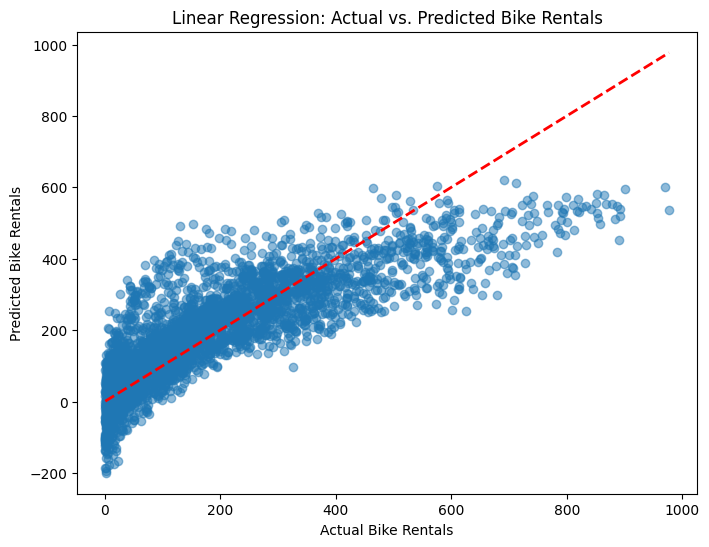

In [16]:
# Your Code here
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_lr_pred, alpha=0.5)

# Add labels and title
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Linear Regression: Actual vs. Predicted Bike Rentals")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

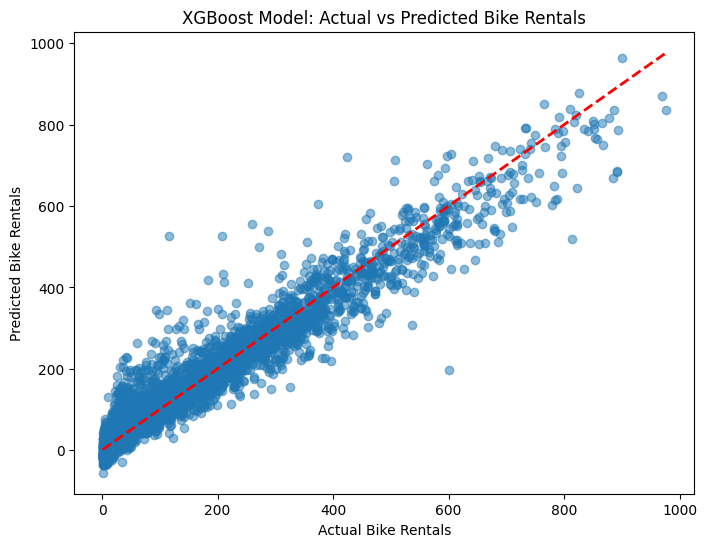

In [17]:
# y_test contains the actual target values for the test dataset
# y_xgb_pred and y_lr_pred contains the predicted values for the test dataset

# Plot actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_xgb_pred, alpha=0.5)

# Add labels and title
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("XGBoost Model: Actual vs Predicted Bike Rentals")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

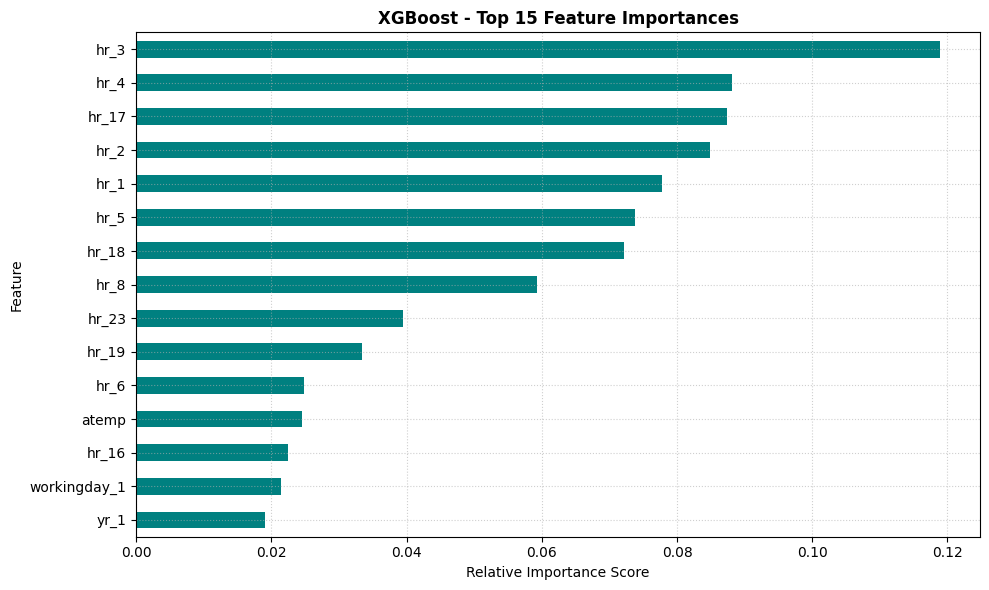

In [18]:
# Top 15 XGBoost Feature Importances Plot
importances = pd.Series(best_xgb.feature_importances_, index=X_train_enc.columns)

plt.figure(figsize=(10, 6))

importances.sort_values(ascending=True).tail(15).plot(kind='barh', color='teal')

plt.title('XGBoost - Top 15 Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()